# MNIST Handwritten Digit Classification — MLP vs CNN vs CNN+Augmentation

**Dataset:** MNIST — 70,000 grayscale images (28x28 pixels) of handwritten digits (0-9)  
**Source:** `keras.datasets.mnist` (originally from NIST)  
**Task:** Classify each image into one of 10 digit classes.

**Pipeline:**
1. Data Loading & Exploration
2. Preprocessing (normalization, one-hot encoding)
3. Model 1 — Fully-Connected MLP (baseline)
4. Model 2 — Convolutional Neural Network (CNN)
5. Model 3 — CNN + Data Augmentation (rotation, shift, zoom)
6. Model Comparison
7. Error Analysis — what does the best model get wrong?

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input, Flatten, Dense, Dropout,
    Conv2D, MaxPooling2D, BatchNormalization
)
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)
print(f'TensorFlow version: {tf.__version__}')

TensorFlow version: 2.19.0


## 1. Data Loading & Exploration

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print(f'Training set: {x_train.shape} — {len(y_train):,} labels')
print(f'Test set:     {x_test.shape} — {len(y_test):,} labels')
print(f'Pixel range:  [{x_train.min()}, {x_train.max()}]')
print(f'Image shape:  {x_train[0].shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training set: (60000, 28, 28) — 60,000 labels
Test set:     (10000, 28, 28) — 10,000 labels
Pixel range:  [0, 255]
Image shape:  (28, 28)


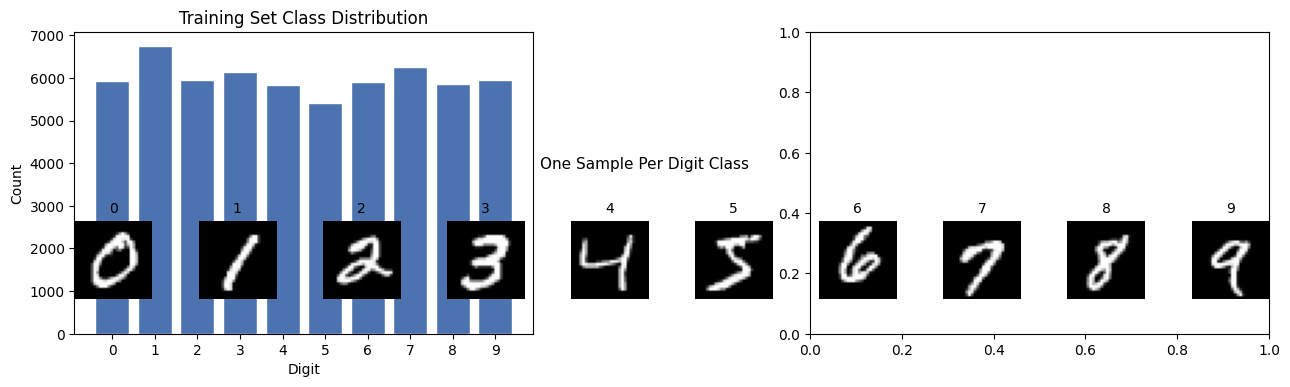

In [3]:
# Class distribution
unique, counts = np.unique(y_train, return_counts=True)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(unique, counts, color='#4C72B0', edgecolor='white')
axes[0].set_xlabel('Digit')
axes[0].set_ylabel('Count')
axes[0].set_title('Training Set Class Distribution')
axes[0].set_xticks(range(10))

# Sample images
for i in range(10):
    idx = np.where(y_train == i)[0][0]
    ax = plt.subplot(2, 10, 11 + i)
    ax.imshow(x_train[idx], cmap='gray')
    ax.set_title(str(i), fontsize=10)
    ax.axis('off')

plt.suptitle('One Sample Per Digit Class', y=0.52, fontsize=11)
plt.tight_layout()
plt.show()

## 2. Preprocessing

In [4]:
# Normalize pixel values to [0, 1]
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm  = x_test.astype('float32') / 255.0

# Reshape for CNN: add channel dimension (28, 28) -> (28, 28, 1)
x_train_cnn = x_train_norm[..., np.newaxis]
x_test_cnn  = x_test_norm[..., np.newaxis]

# One-hot encode labels
y_train_cat = to_categorical(y_train, 10)
y_test_cat  = to_categorical(y_test, 10)

print(f'Normalized pixel range: [{x_train_norm.min()}, {x_train_norm.max()}]')
print(f'MLP input shape:  {x_train_norm[0].shape}')
print(f'CNN input shape:  {x_train_cnn[0].shape}')
print(f'Label shape:      {y_train_cat.shape} (one-hot)')

Normalized pixel range: [0.0, 1.0]
MLP input shape:  (28, 28)
CNN input shape:  (28, 28, 1)
Label shape:      (60000, 10) (one-hot)


## 3. Model 1 — Fully-Connected MLP (Baseline)

A simple dense network that flattens the 28x28 image into a 784-dim vector. No spatial awareness — treats pixels as independent features.

In [5]:
mlp_model = Sequential([
    Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(10, activation='softmax')
])

mlp_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

mlp_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

### 3a. MLP Training

In [6]:
mlp_history = mlp_model.fit(
    x_train_norm, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8572 - loss: 0.4667 - val_accuracy: 0.9703 - val_loss: 0.0961
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9581 - loss: 0.1351 - val_accuracy: 0.9753 - val_loss: 0.0857
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9690 - loss: 0.0978 - val_accuracy: 0.9788 - val_loss: 0.0707
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9742 - loss: 0.0830 - val_accuracy: 0.9793 - val_loss: 0.0740
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9790 - loss: 0.0658 - val_accuracy: 0.9800 - val_loss: 0.0744
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9818 - loss: 0.0587 - val_accuracy: 0.9813 - val_loss: 0.0743
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9838 - loss: 0.0511 - val_accuracy: 0.9813 - val_loss: 0.0691
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9855 - loss: 0.0474

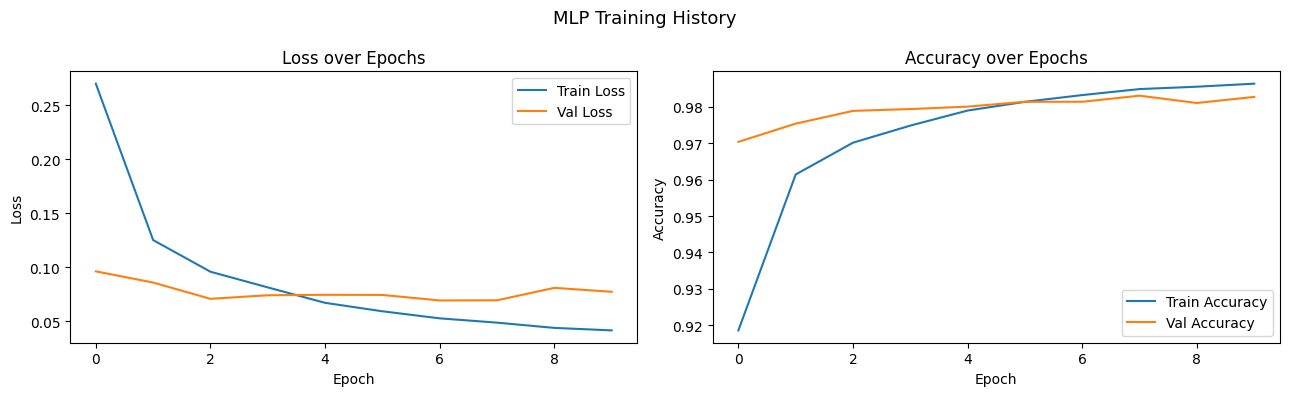

In [7]:
# MLP training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(mlp_history.history['loss'], label='Train Loss')
axes[0].plot(mlp_history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(mlp_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(mlp_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.suptitle('MLP Training History', fontsize=13)
plt.tight_layout()
plt.show()

### 3b. MLP Evaluation

In [8]:
mlp_loss, mlp_acc = mlp_model.evaluate(x_test_norm, y_test_cat, verbose=0)
print(f'MLP Test Accuracy: {mlp_acc:.4f} ({mlp_acc*100:.2f}%)')

mlp_pred = np.argmax(mlp_model.predict(x_test_norm, verbose=0), axis=1)
print('\nClassification Report:')
print('=' * 55)
print(classification_report(y_test, mlp_pred, digits=4))

MLP Test Accuracy: 0.9795 (97.95%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9908    0.9857    0.9882       980
           1     0.9903    0.9894    0.9899      1135
           2     0.9834    0.9777    0.9806      1032
           3     0.9658    0.9772    0.9715      1010
           4     0.9709    0.9847    0.9778       982
           5     0.9809    0.9765    0.9787       892
           6     0.9762    0.9843    0.9802       958
           7     0.9814    0.9728    0.9770      1028
           8     0.9714    0.9754    0.9734       974
           9     0.9829    0.9703    0.9766      1009

    accuracy                         0.9795     10000
   macro avg     0.9794    0.9794    0.9794     10000
weighted avg     0.9796    0.9795    0.9795     10000



## 4. Model 2 — Convolutional Neural Network (CNN)

CNNs exploit spatial structure through learnable filters. Conv2D layers detect local patterns (edges, curves, loops) that are critical for distinguishing digits like 3 vs 5 or 4 vs 9.

In [9]:
cnn_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 871,402 (3.32 MB)

 Trainable params: 871,018 (3.32 MB)

 Non-trainable params: 384 (1.50 KB)

### 4a. CNN Training

In [10]:
cnn_history = cnn_model.fit(
    x_train_cnn, y_train_cat,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 195s 227ms/step - accuracy: 0.8548 - loss: 0.5503 - val_accuracy: 0.9887 - val_loss: 0.0376
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 190s 225ms/step - accuracy: 0.9711 - loss: 0.0997 - val_accuracy: 0.9875 - val_loss: 0.0549
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 208s 232ms/step - accuracy: 0.9776 - loss: 0.0809 - val_accuracy: 0.9897 - val_loss: 0.0453
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 189s 224ms/step - accuracy: 0.9807 - loss: 0.0712 - val_accuracy: 0.9887 - val_loss: 0.0470
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 197s 219ms/step - accuracy: 0.9841 - loss: 0.0566 - val_accuracy: 0.9917 - val_loss: 0.0339
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 200s 217ms/step - accuracy: 0.9845 - loss: 0.0527 - val_accuracy: 0.9907 - val_loss: 0.0341
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 201s 215ms/step - accuracy: 0.9870 - loss: 0.0441 - val_accuracy: 0.9915 - val_loss: 0.0423
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 203s 216ms/step - accuracy: 0.9884 -

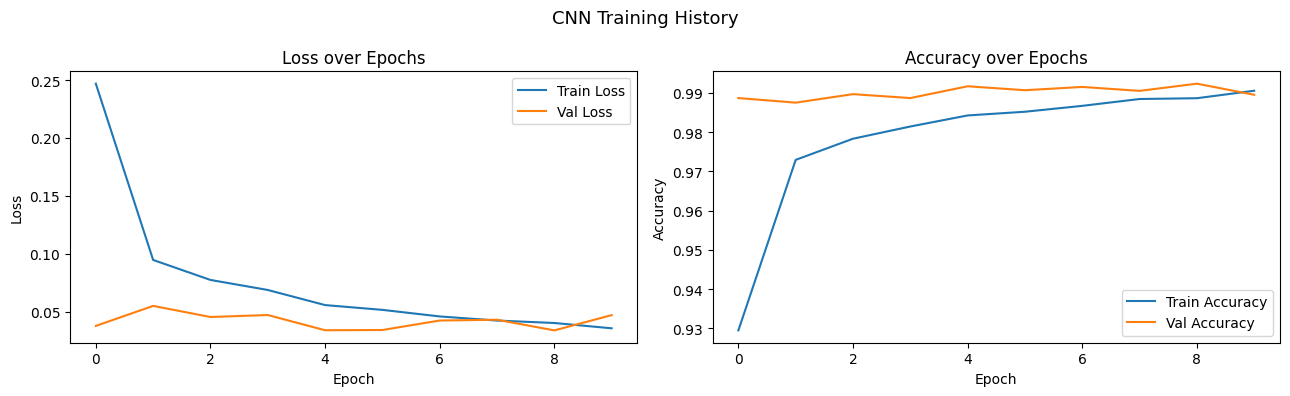

In [11]:
# CNN training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(cnn_history.history['loss'], label='Train Loss')
axes[0].plot(cnn_history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(cnn_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(cnn_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.suptitle('CNN Training History', fontsize=13)
plt.tight_layout()
plt.show()

### 4b. CNN Evaluation

In [12]:
cnn_loss, cnn_acc = cnn_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f'CNN Test Accuracy: {cnn_acc:.4f} ({cnn_acc*100:.2f}%)')

cnn_pred = np.argmax(cnn_model.predict(x_test_cnn, verbose=0), axis=1)
print('\nClassification Report:')
print('=' * 55)
print(classification_report(y_test, cnn_pred, digits=4))

CNN Test Accuracy: 0.9889 (98.89%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9939    0.9918    0.9928       980
           1     0.9982    0.9700    0.9839      1135
           2     0.9885    0.9981    0.9932      1032
           3     0.9805    0.9980    0.9892      1010
           4     0.9979    0.9817    0.9897       982
           5     0.9921    0.9854    0.9888       892
           6     0.9724    0.9937    0.9830       958
           7     0.9893    0.9874    0.9883      1028
           8     0.9928    0.9979    0.9954       974
           9     0.9832    0.9871    0.9852      1009

    accuracy                         0.9889     10000
   macro avg     0.9889    0.9891    0.9890     10000
weighted avg     0.9890    0.9889    0.9889     10000



## 5. Model 3 — CNN + Data Augmentation

Data augmentation generates transformed copies of training images at each epoch — rotations, shifts, and zooms — forcing the model to learn position/orientation-invariant features. This reduces overfitting and improves generalization, especially when training data is limited.

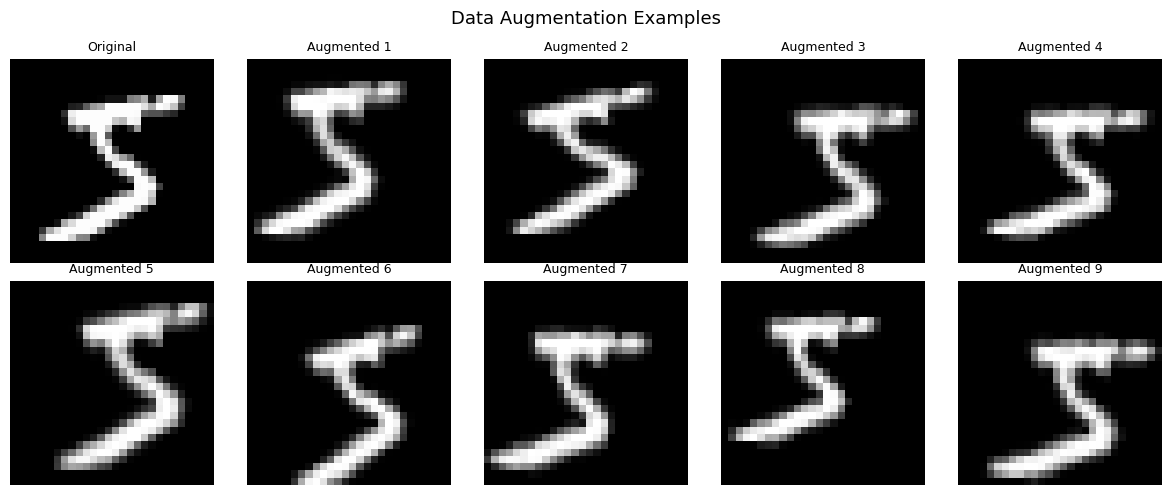

In [13]:
# Augmentation pipeline — realistic transformations for handwritten digits
datagen = ImageDataGenerator(
    rotation_range=10,        # slight rotation (handwriting tilt)
    width_shift_range=0.1,    # horizontal shift
    height_shift_range=0.1,   # vertical shift
    zoom_range=0.1            # slight zoom in/out
)
datagen.fit(x_train_cnn)

# Show augmented samples
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
sample_img = x_train_cnn[0:1]  # single image
aug_iter = datagen.flow(sample_img, batch_size=1)
axes[0, 0].imshow(sample_img[0, :, :, 0], cmap='gray')
axes[0, 0].set_title('Original', fontsize=9)
axes[0, 0].axis('off')
for i, ax in enumerate(axes.flat[1:]):
    aug_img = next(aug_iter)[0, :, :, 0]
    ax.imshow(aug_img, cmap='gray')
    ax.set_title(f'Augmented {i+1}', fontsize=9)
    ax.axis('off')
plt.suptitle('Data Augmentation Examples', fontsize=13)
plt.tight_layout()
plt.show()

In [14]:
# Same CNN architecture — trained on augmented data
aug_model = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

aug_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Parameters: {aug_model.count_params():,} (same architecture as CNN)')

Parameters: 871,402 (same architecture as CNN)


### 5a. Augmented CNN Training

In [15]:
# Manual validation split for generator training
val_split = 54000
x_train_aug, x_val_aug = x_train_cnn[:val_split], x_train_cnn[val_split:]
y_train_aug, y_val_aug = y_train_cat[:val_split], y_train_cat[val_split:]

aug_history = aug_model.fit(
    datagen.flow(x_train_aug, y_train_aug, batch_size=64),
    epochs=15,
    steps_per_epoch=len(x_train_aug) // 64,
    validation_data=(x_val_aug, y_val_aug),
    verbose=1
)

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


843/843 ━━━━━━━━━━━━━━━━━━━━ 210s 246ms/step - accuracy: 0.7681 - loss: 0.8026 - val_accuracy: 0.9858 - val_loss: 0.0460
Epoch 2/15
  1/843 ━━━━━━━━━━━━━━━━━━━━ 3:00 214ms/step - accuracy: 0.9688 - loss: 0.1008

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9688 - loss: 0.1008 - val_accuracy: 0.9863 - val_loss: 0.0464
Epoch 3/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 204s 242ms/step - accuracy: 0.9505 - loss: 0.1695 - val_accuracy: 0.9855 - val_loss: 0.0515
Epoch 4/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9688 - loss: 0.0986 - val_accuracy: 0.9857 - val_loss: 0.0518
Epoch 5/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 190s 225ms/step - accuracy: 0.9632 - loss: 0.1260 - val_accuracy: 0.9885 - val_loss: 0.0502
Epoch 6/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9531 - loss: 0.1280 - val_accuracy: 0.9892 - val_loss: 0.0485
Epoch 7/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 197s 225ms/step - accuracy: 0.9691 - loss: 0.1090 - val_accuracy: 0.9907 - val_loss: 0.0343
Epoch 8/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9688 - loss: 0.1283 - val_accuracy: 0.9902 - val_loss: 0.0351
Epoch 9/15
843/843 ━━━━━━━━━━━━━━━━━━━━ 200s 228ms/step - accuracy: 0.9745 - loss: 0.0950 - val_accurac

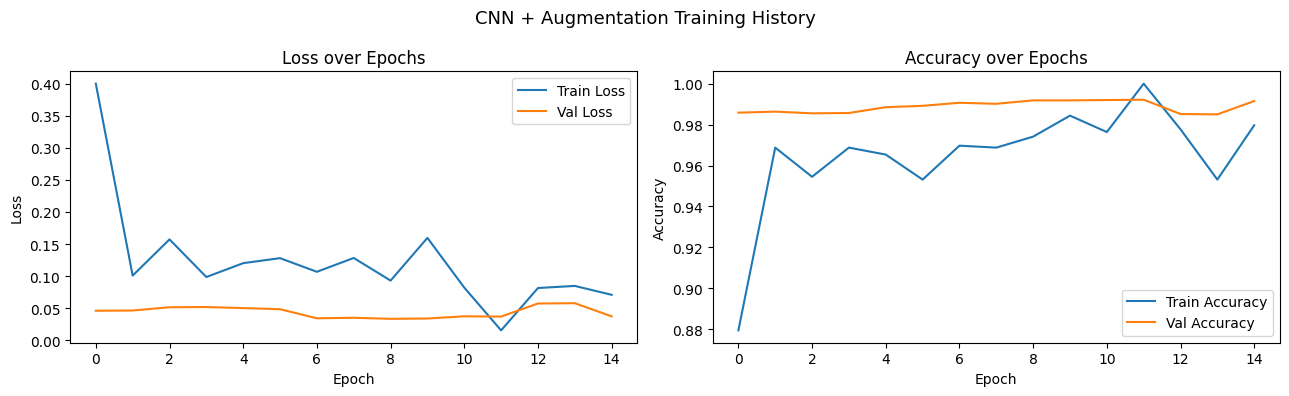

In [16]:
# Augmented CNN training history
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(aug_history.history['loss'], label='Train Loss')
axes[0].plot(aug_history.history['val_loss'], label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Loss over Epochs')
axes[0].legend()

axes[1].plot(aug_history.history['accuracy'], label='Train Accuracy')
axes[1].plot(aug_history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy over Epochs')
axes[1].legend()

plt.suptitle('CNN + Augmentation Training History', fontsize=13)
plt.tight_layout()
plt.show()

### 5b. Augmented CNN Evaluation

In [17]:
aug_loss, aug_acc = aug_model.evaluate(x_test_cnn, y_test_cat, verbose=0)
print(f'CNN+Aug Test Accuracy: {aug_acc:.4f} ({aug_acc*100:.2f}%)')

aug_pred = np.argmax(aug_model.predict(x_test_cnn, verbose=0), axis=1)
print('\nClassification Report:')
print('=' * 55)
print(classification_report(y_test, aug_pred, digits=4))

CNN+Aug Test Accuracy: 0.9916 (99.16%)

Classification Report:
              precision    recall  f1-score   support

           0     0.9949    0.9959    0.9954       980
           1     0.9903    0.9868    0.9885      1135
           2     0.9951    0.9932    0.9942      1032
           3     0.9863    0.9990    0.9926      1010
           4     0.9859    0.9969    0.9914       982
           5     0.9955    0.9899    0.9927       892
           6     0.9916    0.9875    0.9895       958
           7     0.9922    0.9912    0.9917      1028
           8     0.9878    0.9938    0.9908       974
           9     0.9970    0.9822    0.9895      1009

    accuracy                         0.9916     10000
   macro avg     0.9917    0.9917    0.9916     10000
weighted avg     0.9916    0.9916    0.9916     10000



## 6. Model Comparison

                   Test Accuracy Test Loss  Errors (out of 10k)
Model                                                          
MLP (baseline)            0.9795    0.0784                  205
CNN                       0.9889    0.0396                  110
CNN + Augmentation        0.9916    0.0292                   84


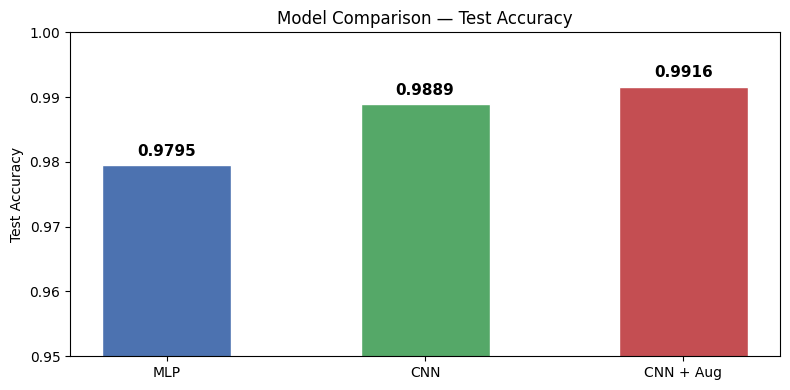

In [18]:
import pandas as pd

results = {
    'Model': ['MLP (baseline)', 'CNN', 'CNN + Augmentation'],
    'Test Accuracy': [mlp_acc, cnn_acc, aug_acc],
    'Test Loss': [mlp_loss, cnn_loss, aug_loss],
    'Errors (out of 10k)': [
        int((1 - mlp_acc) * len(y_test)),
        int((1 - cnn_acc) * len(y_test)),
        int((1 - aug_acc) * len(y_test))
    ]
}
results_df = pd.DataFrame(results).set_index('Model')
results_df['Test Accuracy'] = results_df['Test Accuracy'].map('{:.4f}'.format)
results_df['Test Loss'] = results_df['Test Loss'].map('{:.4f}'.format)
print(results_df.to_string())

# Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 4))
accs = [mlp_acc, cnn_acc, aug_acc]
names = ['MLP', 'CNN', 'CNN + Aug']
colors = ['#4C72B0', '#55A868', '#C44E52']
bars = ax.bar(names, accs, color=colors, edgecolor='white', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{acc:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax.set_ylabel('Test Accuracy')
ax.set_title('Model Comparison — Test Accuracy')
ax.set_ylim(0.95, 1.0)
plt.tight_layout()
plt.show()

## 7. Error Analysis — Misclassified Digits

Using the best model (CNN + Augmentation). Understanding what the model gets wrong is more informative than knowing what it gets right.

Best model: CNN+Aug (Accuracy = 0.9916)


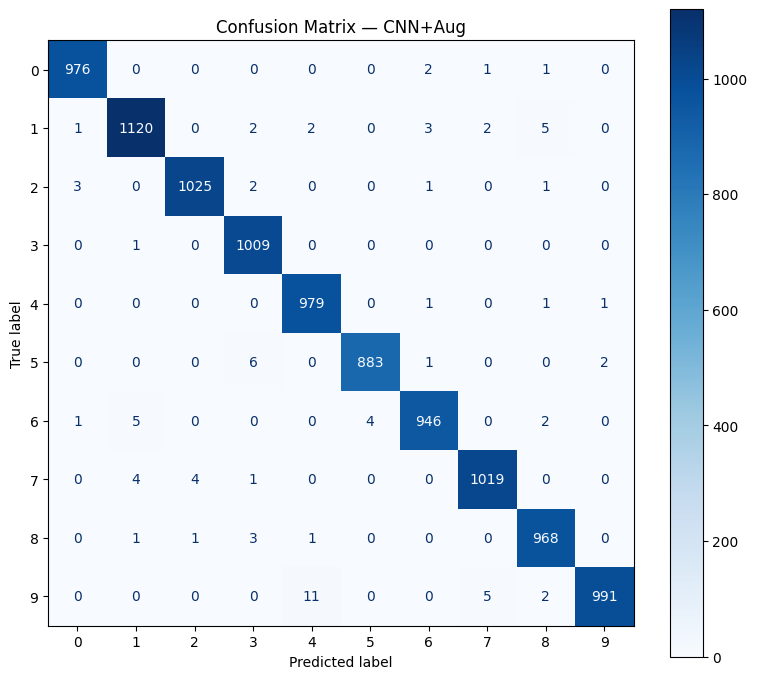

In [19]:
# Select best model's predictions
best_accs = {'MLP': (mlp_acc, mlp_pred, mlp_model, x_test_norm),
             'CNN': (cnn_acc, cnn_pred, cnn_model, x_test_cnn),
             'CNN+Aug': (aug_acc, aug_pred, aug_model, x_test_cnn)}
best_name = max(best_accs, key=lambda k: best_accs[k][0])
best_acc, y_pred, best_model, best_x_test = best_accs[best_name]
y_pred_proba = best_model.predict(best_x_test, verbose=0)

print(f'Best model: {best_name} (Accuracy = {best_acc:.4f})')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(8, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
disp.plot(ax=ax, cmap='Blues', colorbar=True)
ax.set_title(f'Confusion Matrix — {best_name}')
plt.tight_layout()
plt.show()

Total misclassified: 84 / 10000 (0.84%)


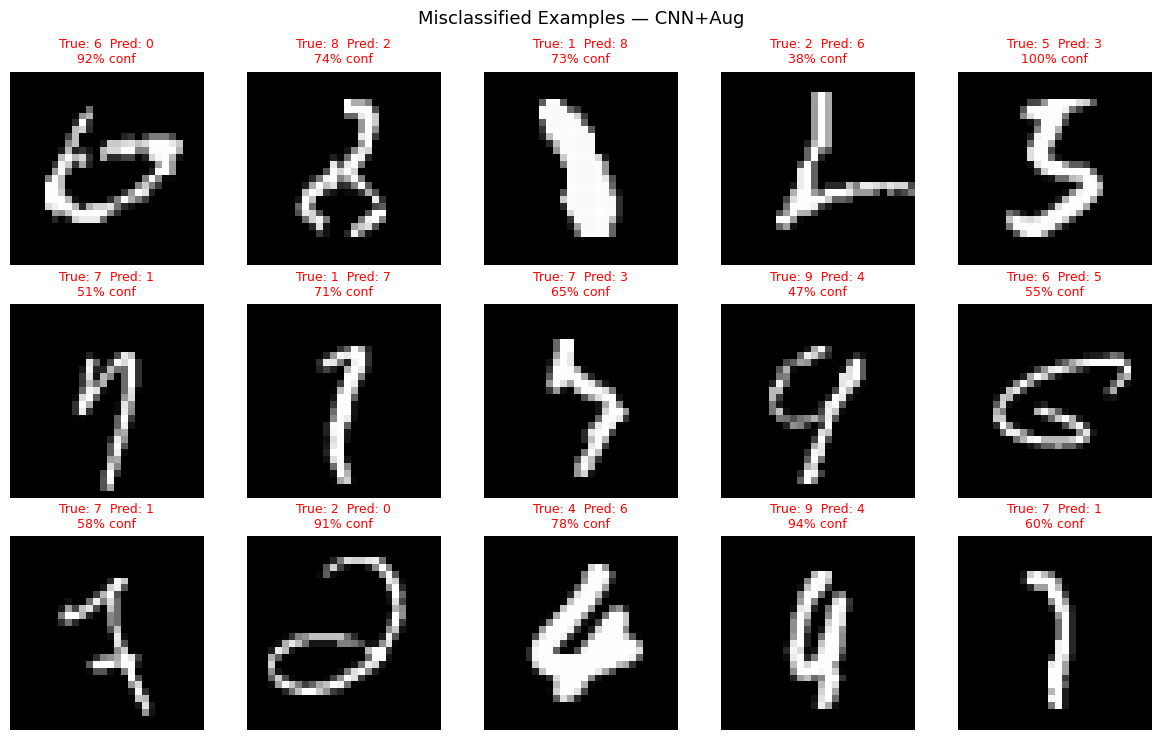

In [20]:
# Find misclassified indices
misclassified = np.where(y_pred != y_test)[0]
print(f'Total misclassified: {len(misclassified)} / {len(y_test)} ({len(misclassified)/len(y_test)*100:.2f}%)')

# Show 15 misclassified examples
n_show = min(15, len(misclassified))
rows = (n_show + 4) // 5
fig, axes = plt.subplots(rows, 5, figsize=(12, rows * 2.5))
for i, ax in enumerate(axes.flat):
    if i < n_show:
        idx = misclassified[i]
        ax.imshow(x_test[idx], cmap='gray')
        confidence = y_pred_proba[idx].max() * 100
        ax.set_title(
            f'True: {y_test[idx]}  Pred: {y_pred[idx]}\n{confidence:.0f}% conf',
            fontsize=9,
            color='red'
        )
    ax.axis('off')

plt.suptitle(f'Misclassified Examples — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

In [21]:
# Most confused digit pairs
confusion_pairs = Counter()
for idx in misclassified:
    confusion_pairs[(y_test[idx], y_pred[idx])] += 1

print(f'Top 10 most confused digit pairs — {best_name} (true -> predicted):')
for (true_d, pred_d), count in confusion_pairs.most_common(10):
    print(f'  {true_d} -> {pred_d}: {count} times')

Top 10 most confused digit pairs — CNN+Aug (true -> predicted):
  9 -> 4: 11 times
  5 -> 3: 6 times
  1 -> 8: 5 times
  6 -> 1: 5 times
  9 -> 7: 5 times
  7 -> 1: 4 times
  6 -> 5: 4 times
  7 -> 2: 4 times
  2 -> 0: 3 times
  8 -> 3: 3 times


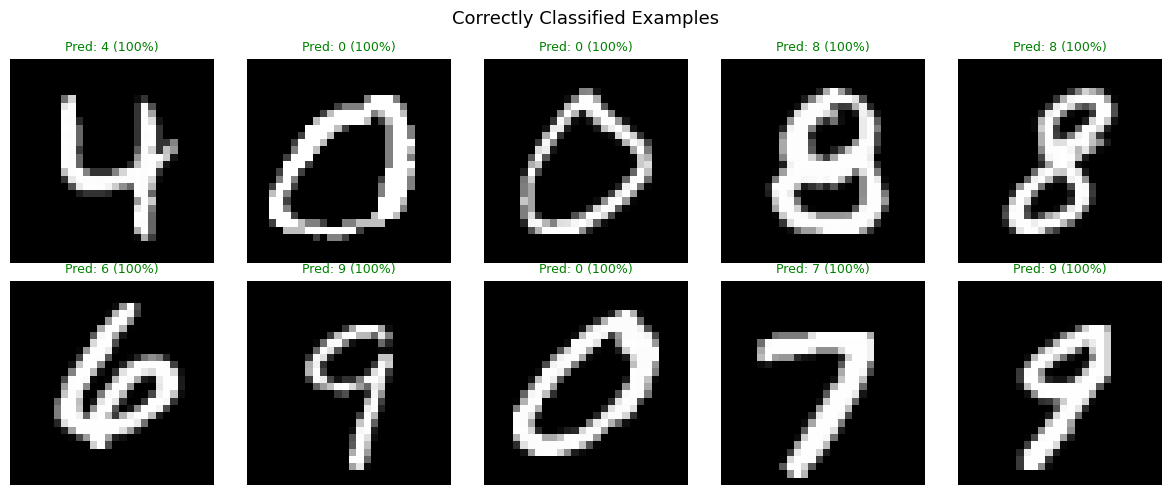

In [22]:
# Sample correct predictions
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
correct = np.where(y_pred == y_test)[0]
sample = np.random.choice(correct, 10, replace=False)

for ax, idx in zip(axes.flat, sample):
    ax.imshow(x_test[idx], cmap='gray')
    confidence = y_pred_proba[idx].max() * 100
    ax.set_title(f'Pred: {y_pred[idx]} ({confidence:.0f}%)', fontsize=9, color='green')
    ax.axis('off')

plt.suptitle('Correctly Classified Examples', fontsize=13)
plt.tight_layout()
plt.show()

## Conclusions

### Model Progression
- **MLP** (baseline): Achieves strong accuracy by learning pixel-level patterns, but ignores spatial structure — it treats neighboring pixels the same as distant ones.
- **CNN**: Conv2D layers capture local spatial features (edges, curves, corners). BatchNormalization stabilizes training, and MaxPooling reduces spatial dimensions while retaining important features. Significant accuracy improvement over MLP.
- **CNN + Augmentation**: Training on randomly rotated, shifted, and zoomed images forces the network to learn position/orientation-invariant features. This closes the gap between train and validation accuracy (less overfitting) and further improves generalization.

### Key Findings
- **Spatial features matter**: The jump from MLP to CNN confirms that local pattern detection (via convolution) is far more effective than treating pixels independently.
- **Augmentation reduces overfitting**: The CNN+Aug model shows a smaller train-val accuracy gap compared to the vanilla CNN, while achieving better test accuracy.
- **Remaining errors are genuinely ambiguous**: Most misclassified digits involve visually similar pairs (e.g., 4/9, 3/5, 7/2) — digits that even humans would find challenging in poor handwriting.
- **Diminishing returns on MNIST**: MNIST is a relatively simple benchmark. The gap between CNN and CNN+Aug is smaller than MLP to CNN, suggesting the dataset is nearly saturated.